In [1]:
print('hello')


hello


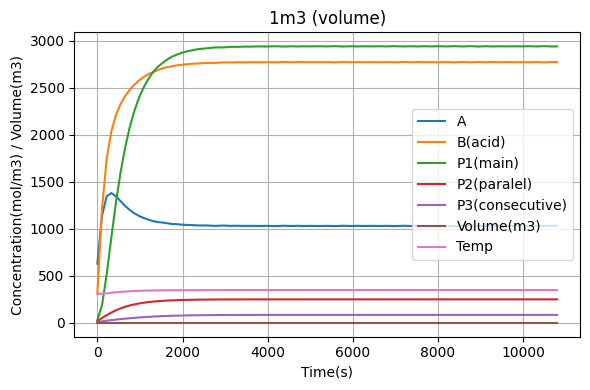


--- Volume Fractions ---
A: 0.170
B: 0.165
P1: 0.606
P2: 0.041
P3: 0.018
Temp: 77.03167444626729
Volume 1 m3 
Residence _Time: 0.5 min


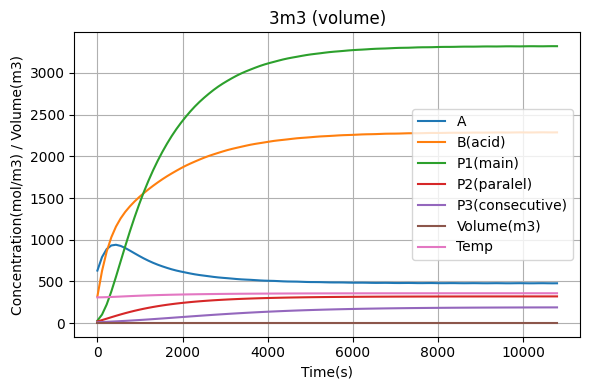


--- Volume Fractions ---
A: 0.079
B: 0.137
P1: 0.691
P2: 0.053
P3: 0.039
Temp: 85.34812253336554
Volume 3 m3 
Residence _Time: 1.5 min


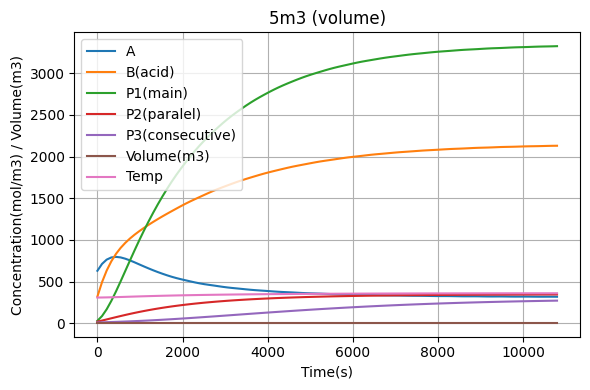


--- Volume Fractions ---
A: 0.054
B: 0.130
P1: 0.701
P2: 0.058
P3: 0.057
Temp: 87.57408981738803
Volume 5 m3 
Residence _Time: 2.5 min


In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

volumes = [1,3,5]

for vol in volumes:
    def reactor(t, y):
        # global V
        Ca, Cb, Cp1, Cp2, Cp3, V, T = y

        V = max(0.01, V) # m3


        # Flow
        F_in = 2 / 1000 # m3/s
        # F_in = 0
        # k_out = 0.7
        F_out  = 2 /1000 # m3/s
        # F_out = k_out * np.sqrt(V)

        # Feed concentrations ( mol/ m3)
        Ca_in  = 3.98 * 1000 
        Cb_in  = 5.60 * 1000
        Cp1_in = 0.15 * 1000
        Cp2_in = 0.13 * 1000
        Cp3_in = 0.05 * 1000

        # Arrhenius
        A1, A2, A3 = 5, 0.05, 0.01
        E1, E2, E3 = 2700, 15600, 17500
        R = 8.314
        # T = Temp # K
        # T = tem + 273  # K
        # print(tem)

        k1 = A1 * np.exp(-E1/(R*T)) * 1e-6  # second order
        k2 = A2 * np.exp(-E2/(R*T)) # j/mol6
        k3 = A3 * np.exp(-E3/(R*T))

        # Rates 
        r1 = k1 * Ca * Cb      # main
        r2 = k2 * Ca           # parallel
        r3 = k3 * Cp1          # consecutive

        #energy balnce 
        density = 865 #kg/m3
        cp = 2000 #j/kg.k

        dh1 = -25000 #j/mol
        dh2 = -12000 #j/mol
        dh3 = -15000 #j/mol

        T_in = 273 + 35

        Q_rn = ((-dh1 * r1) + (-dh2 * r2) + (-dh3 * r3)) 

        dt = ((F_in/V)*(T_in - T) + Q_rn / (density * cp)) 

        # CSTR balances
        dCa = (F_in/V)*Ca_in - (F_out/V)*Ca - (r1 + r2)
        dCb = (F_in/V)*Cb_in - (F_out/V)*Cb - r1
        dCp1 = (F_in/V)*Cp1_in - (F_out/V)*Cp1 + r1 - r3
        dCp2 = (F_in/V)*Cp2_in - (F_out/V)*Cp2 + r2
        dCp3 = (F_in/V)*Cp3_in - (F_out/V)*Cp3 + r3

        dV = F_in - F_out

        # dt =- 0.00000000001

        return [dCa, dCb, dCp1, dCp2, dCp3, dV, dt]
    
    
    # Initial conditions
    # y0 = [0.63, 0.32, 0.03, 0.02, 0.01, 5, 273 + 36]
    y0 = [
        0.63 * 1000,
        0.32 * 1000,
        0.03 * 1000,
        0.02 * 1000,
        0.01 * 1000,
        vol,                 # m3
        273 + 36
    ]

    sol = solve_ivp(
        reactor,
        (0,10* 3600),
        y0,
        t_eval=np.linspace(0, 3*3600, 100)
    )

    # Plot
    
    plt.figure(figsize=(6,4))
    plt.title(f"{vol}m3 (volume)")
    plt.plot(sol.t, sol.y[0], label='A')
    plt.plot(sol.t, sol.y[1], label='B(acid)')
    plt.plot(sol.t, sol.y[2], label='P1(main)')
    plt.plot(sol.t, sol.y[3], label='P2(paralel)') 
    plt.plot(sol.t, sol.y[4], label='P3(consecutive)')
    plt.plot(sol.t, sol.y[5], label='Volume(m3)')
    plt.plot(sol.t, sol.y[6], label='Temp')
  
    plt.xlabel("Time(s)")
    plt.ylabel("Concentration(mol/m3) / Volume(m3)")
    plt.grid()
    plt.tight_layout()
    plt.legend()
    plt.savefig(f"{vol}m3.png")
    plt.show()
    



    MW = {
        "A": 136.24,   # camphene
        "B": 60.05,    # acid
        "P1": 196.29,  # P1
        "P2": 136.24,  # P2 (approx)
        "P3": 196.29   # P3 (approx)
    }

    rho = {
        "A": 0.86,   # kg/L
        "B": 1.05,
        "P1": 0.99,
        "P2": 0.86,
        "P3": 0.99
    }

    Ca, Cb, Cp1, Cp2, Cp3 = sol.y[:5, -1]

    # Convert to volume contributions
    V_A  = Ca  * MW["A"]  / (rho["A"]*1000)
    V_B  = Cb  * MW["B"]  / (rho["B"]*1000)
    V_P1 = Cp1 * MW["P1"] / (rho["P1"]*1000)
    V_P2 = Cp2 * MW["P2"] / (rho["P2"]*1000)
    V_P3 = Cp3 * MW["P3"] / (rho["P3"]*1000)

    V_total = V_A + V_B + V_P1 + V_P2 + V_P3

    # Volume fractions
    vf_A  = V_A  / V_total
    vf_B  = V_B  / V_total
    vf_P1 = V_P1 / V_total
    vf_P2 = V_P2 / V_total
    vf_P3 = V_P3 / V_total

    print("\n--- Volume Fractions ---")
    print(f"A: {vf_A:.3f}")
    print(f"B: {vf_B:.3f}")
    print(f"P1: {vf_P1:.3f}")
    print(f"P2: {vf_P2:.3f}")
    print(f"P3: {vf_P3:.3f}")
    print(f"Temp: {max(sol.y[6]) - 273}")
    print(f"Volume {vol} m3 ")
    print(f"Residence _Time: {vol / 2} min")

